In [1]:
import torch.nn as nn
import torch
from abc import abstractmethod

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Change of variable formula

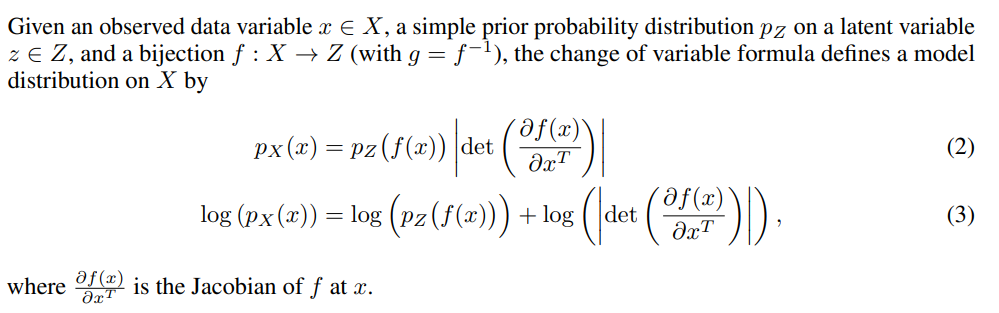

## Coupling Layer

- Computing the Jacobian of functions with high-dimensional domain and codomain and computing
the determinants of large matrices are in general computationally very expensive.

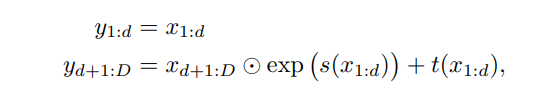

## Properties
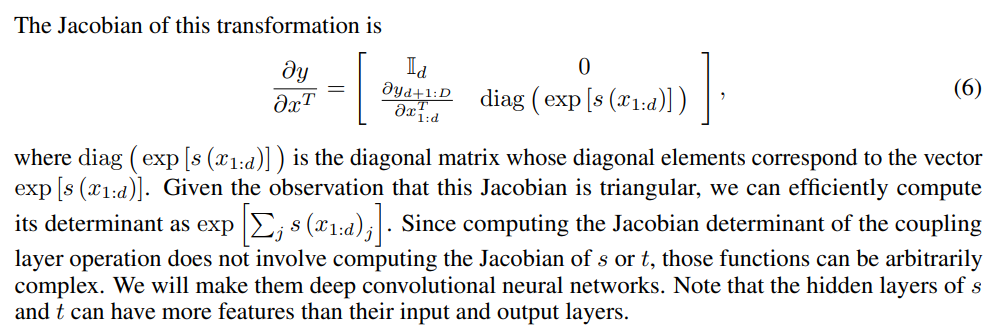

## Masking for Affine Coupling Layers for Image Modelling

#### We use two masking strategy
1. Spatial Checkboard-masking
2. Channel-wise masking

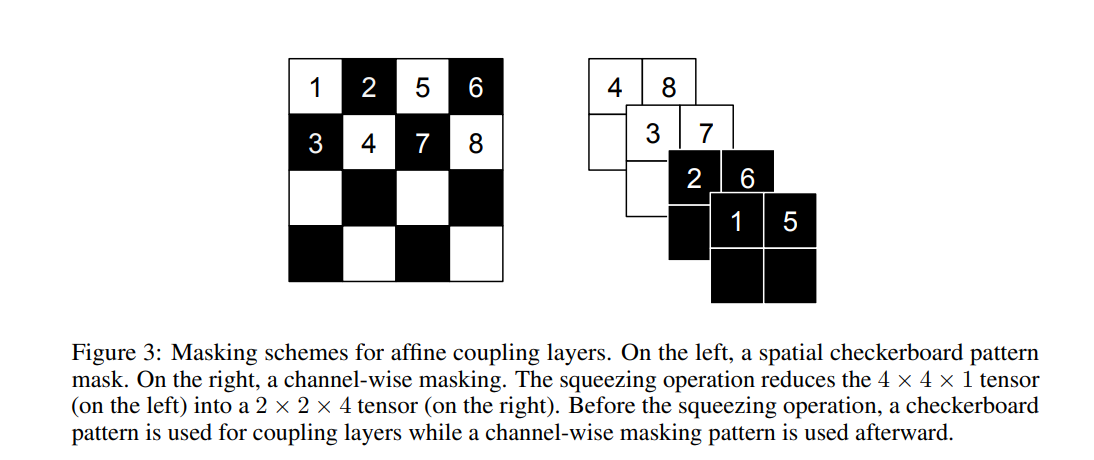

## Masking logic
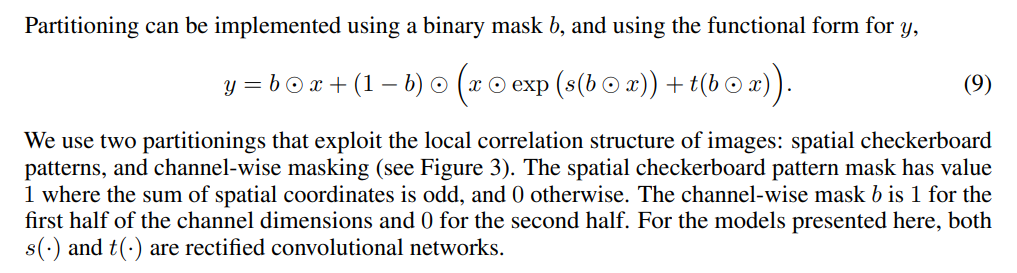

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Implementing these 2 masking techniques

In [3]:
class Masking(nn.Module):
    """
    This class implements 2 masking strategy discussed in this paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    # 2 types of Masking discussed in the paper was

    1. Check-board pattern masking (applied before the squeezing operator)
    2. Channel-wise masking (applied after the squeezing operator)

    Input Shape: [B, C, H, W]
    Output Shape: [B, C, H, W]
    """
    def __init__(self, mask_type: str, first_half: bool | None = None, alternating: bool = False):
        super().__init__()

        self.mask_type = mask_type
        self.first_half = first_half
        self.alternating = alternating

        self.register_buffer("mask_buffer", None)  # lazy init

    def forward(self, x: torch.Tensor):
        """
        Lazy initialization: compute mask only once using input shape
        """
        if self.mask_buffer is None or self.mask_buffer.shape != x.shape:
            self.mask_buffer = self._get_mask(x).to(x.device)

        return self.mask_buffer

    # Check-board masking
    def _get_check_board_masking(self, x: torch.Tensor, alternating: bool = False):
        """
        if alternating == True: The spatial checkerboard pattern mask has value 0 where the sum of spatial coordinates is odd, and 1 otherwise
        if alternating == False: The spatial checkerboard pattern mask has value 1 where the sum of spatial coordinates is odd, and 0 otherwise
        """
        H, W = x.shape[-2], x.shape[-1]

        rows = torch.arange(H, device=x.device).unsqueeze(1)
        cols = torch.arange(W, device=x.device).unsqueeze(0)

        if alternating:
            mask = 1 - ((rows + cols) % 2)
        else:
            mask = (rows + cols) % 2

        return mask.unsqueeze(0).unsqueeze(0)  # [1,1,H,W]

    # Channel-wise masking
    def _get_channel_wise_masking(self, x: torch.Tensor, first_half: bool):
        """
        The channel-wise mask b is 1 for the first half of the channel dimensions and 0 for the second half
        if first_half is true then the masking is applied on the 1st half of the channel else the masking is applied on the 2nd half of the channel, maintaining the alternating pattern for masking

        NOTE: channel_wise making dsn't depends on Height, width and batch so we don't need to create the whole masking as (B, C, H, W) and (1, C, H, W) will work as fine and will produce same result when masking is applied
        This works because pytorch automatically handles the broadcasting for us

        Case-1: mask.shape = B, C, H, W and x.shape = B, C, H, W
        mask * x = B, C, H, W

        Case-2: mask.shape = 1, C, 1, 1 and x.shape = B, C, H, W
        mask * x = (1, C, 1, 1) * (B, C, H, W) => (1, C, 1, 1) will be broadcasted to (B, C, H, W) without creating extra memory and then we will get (mask * x = B, C, H, W)

        Both cases will work, but in case-2 will, memory usage is less and training speed will increase
        """
        _, C, _, _ = x.shape

        mask = torch.zeros(1, C, 1, 1, device=x.device)

        if first_half:
            mask[:, :C//2] = 1
        else:
            mask[:, C//2:] = 1

        return mask

    def _get_mask(self, x: torch.Tensor):
        if self.mask_type == "check_board":
            return self._get_check_board_masking(x, self.alternating)

        elif self.mask_type == "channel_wise" and self.first_half is not None:
            return self._get_channel_wise_masking(x, self.first_half)

        else:
            raise ValueError("Please select available masking [check_board, channel_wise]")

## Squeezing Operator

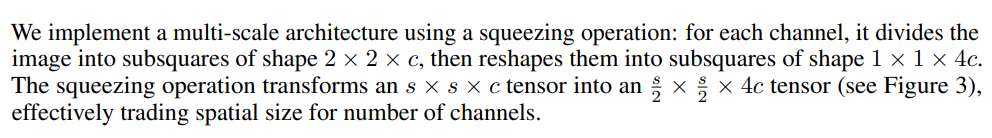

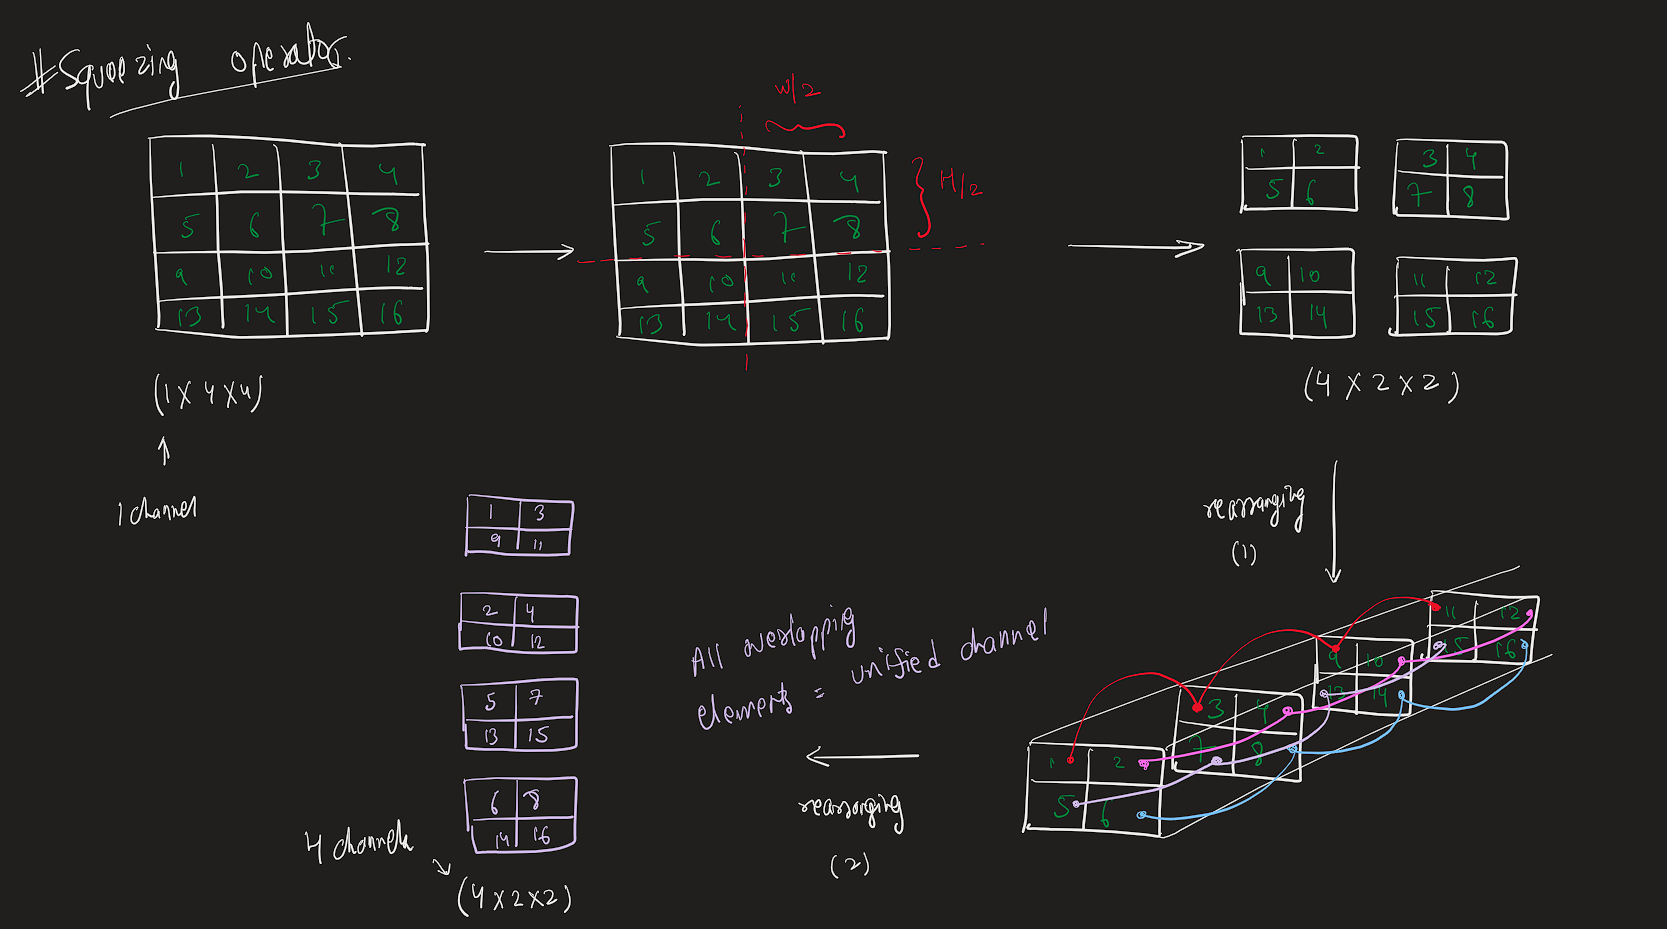

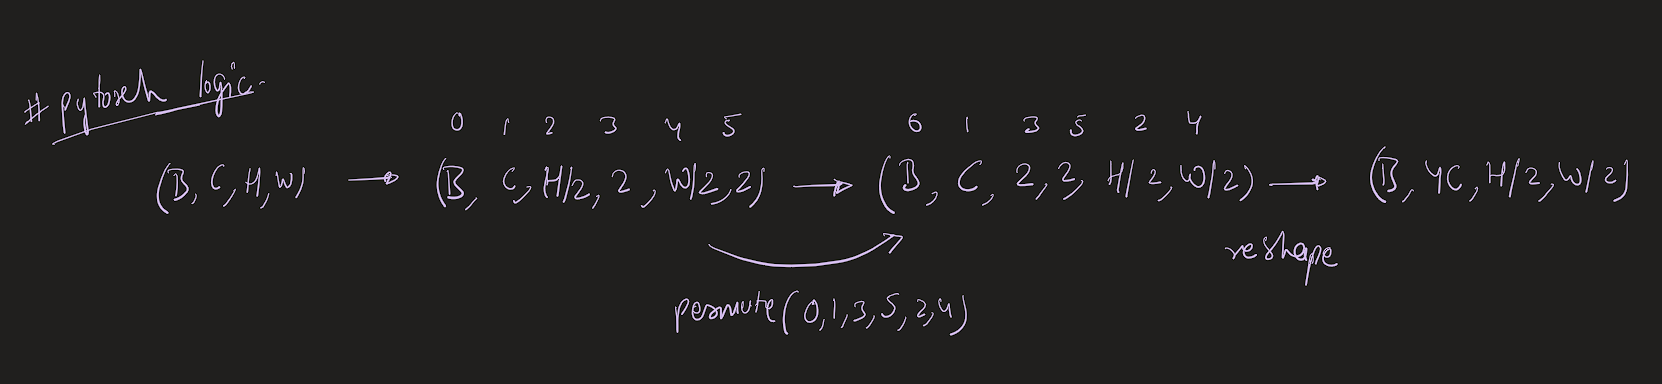

## Batch Normalization

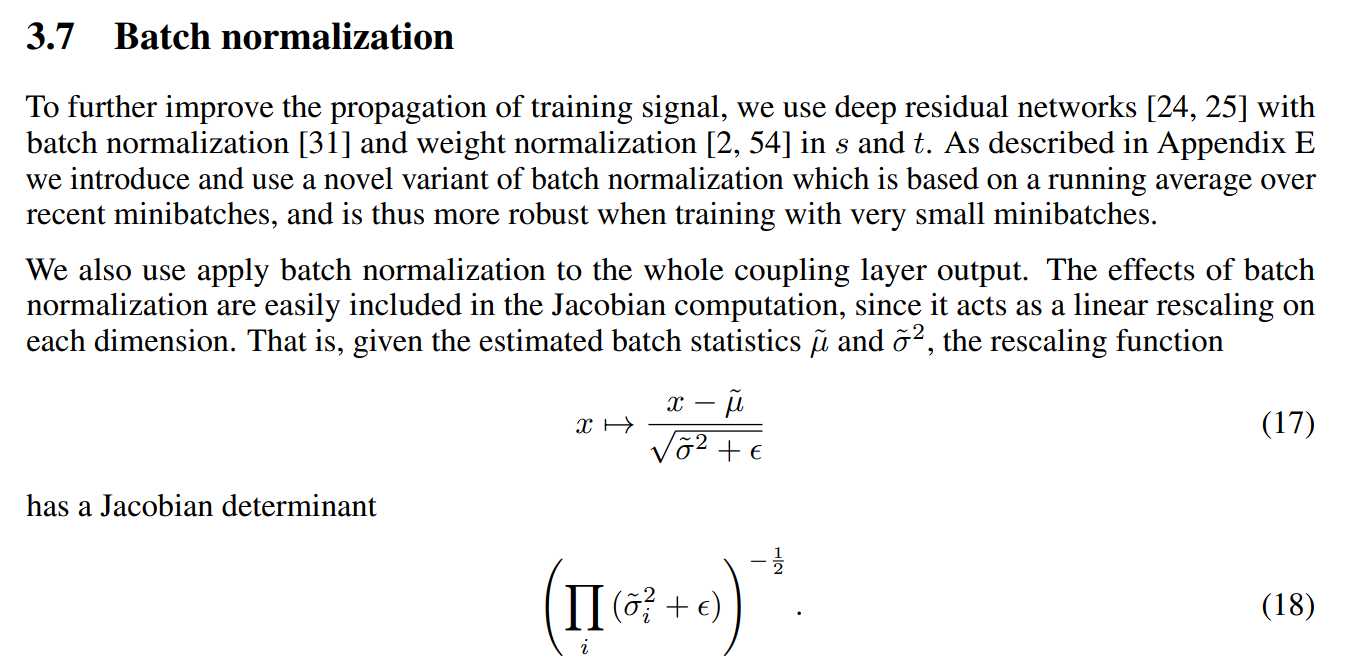

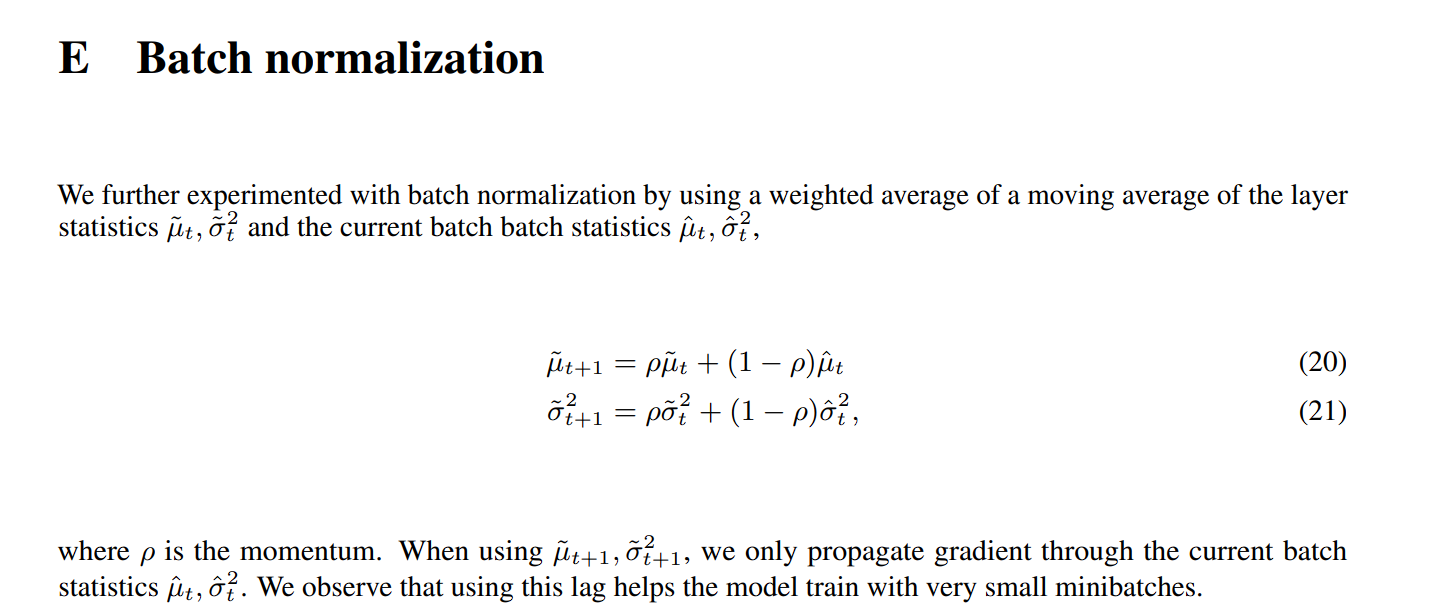

In [4]:
class BatchNormalization(nn.Module):
    """
    This implements the Batch Normalization discussed in 'Section 3.7 Batch normalization' and 'Appendix E: Batch normalization' of paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    I'm using the advanced version discussed in, 'Appendix E: Batch normalization'
    Which is about using batch normalization with weighted averages of a moving average of the layer

    Applies Batch Normalization over a 4D input.
    4D is a mini-batch of 2D inputs with additional channel dimension. Method described in the paper "Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift"
    paper link: https://arxiv.org/pdf/1502.03167

    Input Shape: [B, C, H, W]
    Output Shape: [B, C, H, W]
    """
    def __init__(self, in_channels: int, eps: float = 1e-5, momentum: float = 0.1):
        super().__init__()
        self.in_channels = in_channels
        self.gamma = torch.nn.Parameter(torch.ones(1, in_channels, 1, 1))
        self.beta = torch.nn.Parameter(torch.zeros(1, in_channels, 1, 1))
        self.eps = eps
        self.momentum = momentum

        # buffers (not trainable)
        self.register_buffer(
            "running_mean",
            torch.zeros(1, in_channels, 1, 1)
        )
        self.register_buffer(
            "running_var",
            torch.ones(1, in_channels, 1, 1)
        )
    
    def forward(self, x: torch.Tensor):
        if self.training:
            batch_mean = x.mean(dim = (0, 2, 3), keepdim = True)
            batch_var = x.var(dim = (0, 2, 3), keepdim = True, unbiased = False)
            self.running_mean = ((1 - self.momentum) * self.running_mean + self.momentum * batch_mean)
            self.running_var = ((1 - self.momentum) * self.running_var + self.momentum * batch_var)
            mean = batch_mean
            var = batch_var
        else:
            # if not in training mode (mode = inference mode), then use running_mean and running_var stored during training
            mean = self.running_mean
            var = self.running_var

        x_norm = (x - mean) / (torch.sqrt(var + self.eps))
        return self.gamma * x_norm + self.beta

## Flow Batch Normalization

In [5]:
# class FlowBatchNorm(nn.Module):
#     def __init__(self, num_channels, momentum=0.1, eps=1e-5):
#         super().__init__()
#         self.gamma = nn.Parameter(torch.ones(1, num_channels, 1, 1))
#         self.beta = nn.Parameter(torch.zeros(1, num_channels, 1, 1))
#         self.eps = eps
#         self.momentum = momentum

#         self.register_buffer('running_mean', torch.zeros(1, num_channels, 1, 1))
#         self.register_buffer('running_var', torch.ones(1, num_channels, 1, 1))

#     def forward(self, x):
#         if self.training:
#             with torch.no_grad():
#                 mean = x.mean([0, 2, 3], keepdim=True)
#                 var = x.var([0, 2, 3], keepdim=True, unbiased=False)
                
#                 self.running_mean.mul_(1 - self.momentum).add_(mean * self.momentum) # <---------- we need to keep track of the running mean and var also for the inference to use the batch statistics                                          [Change-02]
#                 self.running_var.mul_(1 - self.momentum).add_(var * self.momentum) # <---------- we need to keep track of the running mean and var also for the inference to use the batch statistics                                             [Change-03]
#         else:
#             mean = self.running_mean
#             var = self.running_var

#         x_hat = (x - mean) / torch.sqrt(var + self.eps)
#         y = self.gamma * x_hat + self.beta

#         _, _, H, W = x.shape
#         # log_det = torch.sum(torch.log(torch.abs(self.gamma)) - 0.5 * torch.log(var + self.eps)) * H * W <-------- This is wrong                                             [Change-04]
#         log_det_single = (torch.log(torch.abs(self.gamma)) - 0.5 * torch.log(var + self.eps)).sum() * H * W
#         return y, log_det_single.expand(x.shape[0])

#     def inverse(self, y):
#         mean = self.running_mean
#         var = self.running_var

#         x_hat = (y - self.beta) / self.gamma
#         x = x_hat * torch.sqrt(var + self.eps) + mean
        
#         # Compute inverse log determinant
#         _, _, H, W = y.shape
#         log_det_inv = -(torch.log(torch.abs(self.gamma)) - 0.5 * torch.log(var + self.eps)).sum() * H * W
        
#         return x, log_det_inv.expand(y.shape[0])


class FlowBatchNorm(nn.Module):
    """Fixed version with proper log-det handling"""
    
    def __init__(self, num_channels, momentum=0.1, eps=1e-5):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(1, num_channels, 1, 1))
        self.beta = nn.Parameter(torch.zeros(1, num_channels, 1, 1))
        self.eps = eps
        self.momentum = momentum
        self.register_buffer('running_mean', torch.zeros(1, num_channels, 1, 1))
        self.register_buffer('running_var', torch.ones(1, num_channels, 1, 1))
        self.mean_stack = []
        self.var_stack = []

    def forward(self, x):
        if self.training:
            # Compute batch statistics
            mean = x.mean([0, 2, 3], keepdim=True)
            var = x.var([0, 2, 3], keepdim=True, unbiased=False)
            
            # Update running statistics (without gradient)
            with torch.no_grad():
                self.running_mean.mul_(1 - self.momentum).add_(mean * self.momentum)
                self.running_var.mul_(1 - self.momentum).add_(var * self.momentum)
        else:
            # Use running statistics at inference
            mean = self.running_mean
            var = self.running_var
        
        # self.last_mean = mean  # <------------- Storing this for the inverse
        # self.last_var = var


        self.mean_stack.append(mean.detach())
        self.var_stack.append(var.detach())

        # Normalize
        x_hat = (x - mean) / torch.sqrt(var + self.eps)
        y = self.gamma * x_hat + self.beta

        # Compute log determinant (same for all batches in this call)
        _, _, H, W = x.shape
        log_det_single = (torch.log(torch.abs(self.gamma)) - 0.5 * torch.log(var + self.eps)).sum() * H * W
        
        # Return as [B] shaped tensor
        return y, log_det_single.expand(x.shape[0])

    def inverse(self, y):
        """FIXED: Now returns (x, log_det_inv) for invertibility"""
        # mean = self.last_mean
        # var = self.last_var

        mean = self.mean_stack.pop()
        var  = self.var_stack.pop()

        x_hat = (y - self.beta) / self.gamma
        x = x_hat * torch.sqrt(var + self.eps) + mean
        
        # Compute inverse log determinant
        _, _, H, W = y.shape
        log_det_inv = -(torch.log(torch.abs(self.gamma)) - 0.5 * torch.log(var + self.eps)).sum() * H * W
        
        return x, log_det_inv.expand(y.shape[0])

# avg_error = 0
# for _ in range(100):
#     x = torch.randn(10, 3, 64, 64)
#     f = FlowBatchNorm(
#         3
#     )
#     y, _ = f(x)
#     inverse, _ = f.inverse(y)
#     error = (x-inverse).abs().mean()
#     avg_error += error

# avg_error /= 100

# print(f"error = {(x - inverse).abs().max()} | layer_name = {type(f)}")



## Squeezing Operator

In [6]:
class SqueezingOperator(nn.Module):
    """
    This Implements the Squeezing Operator discussed in 'Section 3.6 Multi-scale architecture' in the paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    It divides the image into subsquares of shape 2 x 2 x c, then reshapes them into subsquares of shape 1 x 1 x 4c

    For forward pass:
        Input Shape: [B, C, H, W]
        Output Shape: [B, 4*C, H/2, W/2]

    For inverse pass:
        Input Shape: [B, 4*C, H/2, W/2]
        Output Shape: [B, C, H, W]
    """
    def __init__(self):
        super().__init__()
    
    @abstractmethod
    def forward(self, x: torch.Tensor):
        return self._squeeze(x)

    def _squeeze(self, x: torch.Tensor):
        """
        
        # Why we squeeze the image?
        1. Squeezing is used to reorganize information so the model can learn dependencies more effectively
        2. without squeezing information spreads slowly across spatial positions
        """
        B, C, H, W = x.shape
        x = x.view(B, C, H//2, 2, W//2, 2) # dividing into subgroups of 2x2
        x = x.permute(0, 1, 3, 5, 2, 4) # bring subgroups of 2x2 near channel-dim
        x = x.reshape(B, 4*C, H//2, W//2)
        return x
    
    def _unsqueeze(self, x: torch.Tensor):
        # x.shape = [B, 4*C, H/2, W/2]
        B, C, H, W = x.shape
        x = x.reshape(B, C//4, 2, 2, H, W)
        x = x.permute(0, 1, 4, 2, 5, 3)
        x = x.reshape(B, C//4, 2*H, 2*W)
        return x

    
    def inverse(self, x: torch.Tensor):
        return self._unsqueeze(x)


# Usage:

# s = SqueezingOperator()
# x = torch.rand(10, 3, 64, 64)
# squ_x = s(x)
# unsqu_x = s.inverse(squ_x)
# # print(f"x = {x[0, 0, 0, :5]}")
# # print(f"squeeze_x = {squ_x[0, 0, 0, :5]}")
# # print(f"unsqueeze_x = {unsqu_x[0, 0, 0, :5]}")
# print(f"error = {(x - unsqu_x).abs().max()} | layer_name = {type(s)}")

## Residual Skip Connections

In [7]:
class ResidualSkipConnections(nn.Module):
    """
    Implementing Residual Skip connections for efficient gradient flow as discussed in the paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    Input Shape: [B, C, H, W]
    Output Shape: [B, C, H, W]
    """
    def __init__(self, function: nn.Module):
        super().__init__()
        self.function = function

    def forward(self, x: torch.Tensor):
        out = self.function(x)
        return x + out

In [8]:
import torch.nn.functional as F

class Block(nn.Module):
    """
    This denotes 1 block of the scale and shift network, we repeat multiple blocks in scale and shift Network to make complex deep neural nets
    Defination of 1 Block:
    [
        ResidualSkipConnections(Conv2d() --> BatchNorm() --> Conv2d() --> BatchNorm() --> Conv2d() --> BatchNorm()) 
        --> Relu()
    ] x 5

    Input Shape: [B, C, H, W]
    Output Shape: [B, C, H, W]
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        assert in_channels == out_channels, "in_channels must be equal to out_channels"
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.conv1 = nn.Conv2d(in_channels = self.in_channels, out_channels = 128, kernel_size = 3, stride = 1, padding = 1) # Using padding  = 1, because I want h_in = h_out ==> x_in.shape == x_out.shape after applying scale and shift transformation
        # self.batchnorm2d_1 = BatchNormalization(in_channels = 32)
        self.conv2 = nn.Conv2d(in_channels = 128, out_channels = 128, kernel_size = 3, stride = 1, padding = 1)
        # self.batchnorm2d_2 = BatchNormalization(in_channels = 32)
        self.conv3 = nn.Conv2d(in_channels = 128, out_channels = self.out_channels, kernel_size = 3, stride = 1, padding = 1) # <------ Added weight_norm mentioned in the paper                              [Change-05]
        # self.batchnorm2d_3 = BatchNormalization(in_channels = self.out_channels)
        # self.channel_mix = nn.Conv2d(out_channels, out_channels, kernel_size=1)

        self.in_mix  = nn.Conv2d(in_channels, in_channels, 1)
        self.out_mix = nn.Conv2d(out_channels, out_channels, 1)

        # proper Initializations
        nn.init.zeros_(self.conv3.weight)
        nn.init.zeros_(self.conv3.bias)
        nn.init.zeros_(self.out_mix.weight)
        nn.init.zeros_(self.out_mix.bias)

        nn.init.orthogonal_(self.in_mix.weight)
        nn.init.orthogonal_(self.out_mix.weight)
        nn.init.zeros_(self.in_mix.bias)
        nn.init.zeros_(self.out_mix.bias)
    
    def forward(self, x: torch.Tensor):
        residual = x
        x = self.in_mix(x)
        x = F.leaky_relu(self.conv1(x))
        # x = self.batchnorm2d_1(x)
        x = F.leaky_relu(self.conv2(x))
        # x = self.batchnorm2d_2(x)
        x = self.conv3(x)
        # x = self.batchnorm2d_3(x)
        # x = self.channel_mix(x)
        x = self.out_mix(x)
        return x + residual

## Scale and Shift Neural Network

In [9]:
import torch.nn.functional as F
class ScaleAndShiftNetwork(nn.Module):
    """
    This class implements the scale and shift logic discussed in this paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    This Class can be very complex Neural Network because the Jacobian determinant have no contribution for this component
    as discussed in the the above paper in section 3.3 Properties "We will make them deep convolutional neural networks", i'll also implement this scale and shift network as deep CNNs

    In section (3.7 Batch normalization) they also discussed to apply Batch Normalization (novel variant) with residual connections and weight normalization to implement this scale and shift networks
    Novel variant of batch normalization is discussed in Appendix E, which is based on a running average over recent minibatches

    No MaxPooling or squeeze is used inside scale and shift networks because spatial dimensions must remain unchanged for affine coupling

    Architecture of Scale and Shift Network as Deep CNNs:
    [
        ResidualSkipConnections(Conv2d() --> BatchNorm() --> Conv2d() --> BatchNorm()) 
        --> Relu()
    ] x 5
    Residual Skip Connections will wrap Conv2d, BatchNorm and not relu

    Input Shape: [B, C, H, W]
    Output Shape: [B, C, H, W]
    """
    def __init__(self, in_channels: int, out_channels: int, n_layers: int):
        super().__init__()
        assert in_channels == out_channels, "in_channels must be equal to out_channels"
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.cnn_layer = nn.ModuleList([
            ResidualSkipConnections(Block(self.in_channels, self.out_channels))
            # Block(self.in_channels, self.out_channels)
            for _ in range(n_layers)
        ])
        self.scale_layer = nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = 3, padding = 1, stride = 1)
        self.shift_layer = nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = 3, padding = 1, stride = 1)
        nn.init.zeros_(self.scale_layer.weight)
        nn.init.zeros_(self.scale_layer.bias)
        nn.init.zeros_(self.shift_layer.weight)
        nn.init.zeros_(self.shift_layer.bias)
    
    def forward(self, x: torch.Tensor):
        for layer in self.cnn_layer:
            x = layer(x)
            x = F.leaky_relu(x, negative_slope = 0.01) # <------using leakly relu instead of relu                                           [Change-06]
        return self.scale_layer(x), self.shift_layer(x)

## Affine Coupling Layer

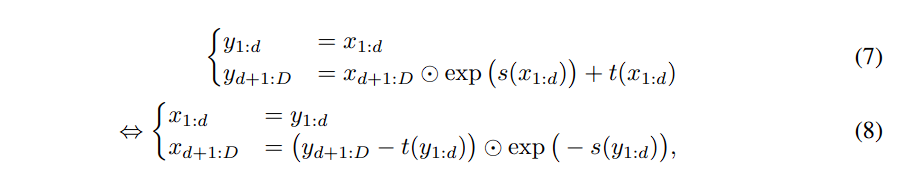

In [10]:
class AffineCouplingLayer(nn.Module):
    """
    This class Implements the affine coupling layer using Masked convolution, as discussed in "section 3.4 Masked convolution" of paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    b = binary_mask (spatial checkerboard pattern mask or channel-wise mask)
    x = input_vector

    In-practice we will get (x_a, x_b) = (b * x, (1-b) * x)
    (y_a, y_b) = (exp(scale(x_b) * x_a + shift(x_b)), x_b)
    where 'x_b' is left unchanged

    Input Shape: [B, C, H, W]
    Output Shape: [B, C, H, W]
    """
    def __init__(self, mask_type: str, first_half: bool | None, in_channel: int, out_channel: int, n_layers: int, alternating_check_board: bool = False):
        super().__init__()
        assert in_channel == out_channel, "in_channels must be equal to out_channels"
        self.mask_type = mask_type
        self.alternating_check_board = alternating_check_board
        self.first_half = first_half
        self.scale_shift = ScaleAndShiftNetwork(in_channels = in_channel, out_channels = out_channel, n_layers = n_layers)
        # self.scale_factor = nn.Parameter(torch.zeros(1))
        self.scale_factor = torch.tensor(0.7)
        # self.register_buffer("scale_factor", torch.tensor(0.1))
        self.mask_module = Masking(
            mask_type=self.mask_type,
            first_half=self.first_half,
            alternating=self.alternating_check_board
        )

    def forward(self, x: torch.Tensor):
        b = self.mask_module(x)
        scale, shift = self.scale_shift(b * x)
        # scale = torch.exp(self.scale_factor) * torch.tanh(scale)
        scale = self.scale_factor * torch.tanh(scale)
        # scale = torch.clamp(scale, -0.2, 0.2)
        y = b * x + (1- b) * (x * torch.exp(scale) + shift)
        log_det = (1-b) * scale

        self._scale = scale # for debugging

        return y, log_det # <---- This is for the Determinant of the Jacobian matrix
    
    def inverse(self, y: torch.tensor):
        """
        Calculates the inverse of Affine Coupling Layer, the defination of this inverse is attached in the above markdown cell
        """
        b = self.mask_module(y)

        y1, y2 = y * b, y * (1 - b)
        s, t = self.scale_shift(y1)
        # scale = torch.exp(self.scale_factor) * torch.tanh(s)
        scale = self.scale_factor * torch.tanh(s)
        # scale = torch.clamp(scale, -0.2, 0.2)
        x1 = y1
        x2 = (1 - b) * (y2 - t) * torch.exp(-scale)
        return x1 + x2

# Usage:

# x = torch.randn(10, 3, 64, 64)
# layer = AffineCouplingLayer(
#     mask_type="check_board",
#     first_half=None,
#     in_channel=3,
#     out_channel=3,
#     n_layers=5,
#     alternating_check_board=False
# )
# y, _ = layer(x)
# x_hat = layer.inverse(y)
# print(f"error = {(x - x_hat).abs().max()} | layer_name = {type(layer)}")

## Multi-scale Architecture

In [11]:
# class ScaleBlock(nn.Module):
#     """
#     This imnplements one Scale block of the Multi-scale Architecture discussed in Multi-scale architecture discussed in 'section 3.6 Multi-scale architecture' of paper: DENSITY ESTIMATION USING REAL NVP
#     paper link: https://arxiv.org/pdf/1605.08803


#     It first applies three coupling layers (AffineCouplingLayer)
#     with alternating checkerboard masks, then perform a squeezing operation, and finally apply three
#     more coupling layers with alternating channel-wise masking
#     For the final scale, it only applies four coupling layers with alternating checkerboard masks <----- Implemented by 'FinalScaleBlock' class

#     Architecture:
#     Each Scale: Defined here in ScaleBlock class
#         AffineCouplingLayer() x 3 (use alternating checkerboard masking)
#         SqueezingOperation()
#         AffineCouplingLayer() x 3 (use alternating channel-wise masking)
#         SplitLatent()
#     Final Scale: Defined in FinalScaleBlock class
#         AffineCouplingLayer() x 4 (use alternating checkerboard masking)

    
#     Each Scale:
#     Produces latent chunk


#     Input Shape: [B, C, H, W]
#     Output Shape: [B, 4*C, H/2, W/2] <--- because of SqueezingOperator()
#     """
#     def __init__(self, in_channel: int, out_channel: int, n_scale_shift_layers: int):
#         super().__init__()
#         self.check_board_layer = nn.ModuleList([
#             AffineCouplingLayer(mask_type = "check_board", alternating_check_board = False, first_half = None, in_channel = in_channel, out_channel = out_channel, n_layers = n_scale_shift_layers),
#             FlowBatchNorm(out_channel),
#             AffineCouplingLayer(mask_type = "check_board", alternating_check_board = True, first_half = None, in_channel = in_channel, out_channel = out_channel, n_layers = n_scale_shift_layers),
#             FlowBatchNorm(out_channel),
#             AffineCouplingLayer(mask_type = "check_board", alternating_check_board = False, first_half = None, in_channel = in_channel, out_channel = out_channel, n_layers = n_scale_shift_layers)
#         ])

#         self.squeeze = SqueezingOperator() # <----- After performing this, in_channel get's changed, it gets 4 * original_in_channel

#         self.channel_wise_layer = nn.ModuleList([
#             AffineCouplingLayer(mask_type = "channel_wise", first_half = True, in_channel = 4 * in_channel, out_channel = 4 * out_channel, n_layers = n_scale_shift_layers),
#             FlowBatchNorm(4 * out_channel),
#             AffineCouplingLayer(mask_type = "channel_wise", first_half = False, in_channel = 4 * in_channel, out_channel = 4 * out_channel, n_layers = n_scale_shift_layers),
#             FlowBatchNorm(4 * out_channel),
#             AffineCouplingLayer(mask_type = "channel_wise", first_half = True, in_channel = 4 * in_channel, out_channel = 4 * out_channel, n_layers = n_scale_shift_layers)
#         ])

    
#     def forward(self, x: torch.Tensor):
#         # Apply 1st 3-layers of ScaleBlock
#         log_det = 0
#         for layer in self.check_board_layer:
#             x, ld = layer(x) # x.shape = (B, C, H, W) ---> x.shape = (B, C, H, W)
#             if ld.ndim == 4:
#                 log_det += torch.sum(ld, dim=[1,2,3])
#             else:
#                 log_det += ld
        
#         # Squeeze it
#         x = self.squeeze(x) # x.shape = (B, C, H, W) ---> x.shape = (B, 4*C, H/2, W/2)


#         # Apply last 3 layers of ScaleBlock
#         for layer in self.channel_wise_layer:
#             x, ld = layer(x) # x.shape = (B, 4*C, H/2, W/2) ---> x.shape = (B, 4*C, H/2, W/2)
#             if ld.ndim == 4:
#                 log_det += torch.sum(ld, dim=[1,2,3])
#             else:
#                 log_det += ld

#         # Next ScaleBlock's check_board_layer will expect the tensor of shape (B, C, H, W) but right now the shape of x tensor is (B, 4*C, H/2, W/2) --> mismatch in shape, therefore we use Latent vector splitting

#         # Split
#         B, C, H, W = x.shape
#         z = x[:, C//2:] # <---------------- VERY IMPORTANT CHANGE: I realized this after 12-13 hrs of wrong training and debudding, i'm factoring out the unchanged part instead of transformed part                                    [Change-07]
#         x_remaining = x[:, :C//2] # <-------------- This will also get's changed and the inverse needs an update too

#         # ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
#         # ISSUE:
#         # The Issue: The Real NVP architecture is designed to factor out the variables that have just been processed (transformed) into a Gaussian distribution.
#         # By factoring out the part that was just used as context (the unchanged part), I'm essentially throwing away raw data and trying to perform complex flow operations on the "noise" that i've just created.
#         # ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#         # Now next layer will get this x_remaining (x_remaining.shape = [B, 2*C, H/2, W/2])
#         return x_remaining, z, log_det
    
#     def inverse(self, x_remaining: torch.Tensor, z: torch.Tensor):
#         """
#         Aim is to re-create input x from x_remaining and z which is a very complex transformation of x
#         """
#         B, C, H, W = x_remaining.shape
#         x = torch.cat([x_remaining, z ], dim=1)

#         for layer in self.channel_wise_layer[::-1]:
#             x = layer.inverse(x)

#         x = self.squeeze.inverse(x)

#         for layer in self.check_board_layer[::-1]:
#             x = layer.inverse(x)
        
#         return x

class ScaleBlock(nn.Module):
    """Fixed version with consistent log_det shapes"""
    
    def __init__(self, in_channel: int, out_channel: int, n_scale_shift_layers: int):
        super().__init__()
        self.check_board_layer = nn.ModuleList([
            AffineCouplingLayer(mask_type="check_board", alternating_check_board=False, 
                              first_half=None, in_channel=in_channel, out_channel=out_channel, 
                              n_layers=n_scale_shift_layers),
            # FlowBatchNorm(out_channel),
            AffineCouplingLayer(mask_type="check_board", alternating_check_board=True, 
                              first_half=None, in_channel=in_channel, out_channel=out_channel, 
                              n_layers=n_scale_shift_layers),
            # FlowBatchNorm(out_channel),
            AffineCouplingLayer(mask_type="check_board", alternating_check_board=False, 
                              first_half=None, in_channel=in_channel, out_channel=out_channel, 
                              n_layers=n_scale_shift_layers)
        ])

        self.squeeze = SqueezingOperator()

        self.channel_wise_layer = nn.ModuleList([
            AffineCouplingLayer(mask_type="channel_wise", first_half=True, 
                              in_channel=4*in_channel, out_channel=4*out_channel, 
                              n_layers=n_scale_shift_layers),
            # FlowBatchNorm(4*out_channel),
            AffineCouplingLayer(mask_type="channel_wise", first_half=False, 
                              in_channel=4*in_channel, out_channel=4*out_channel, 
                              n_layers=n_scale_shift_layers),
            # FlowBatchNorm(4*out_channel),
            AffineCouplingLayer(mask_type="channel_wise", first_half=True, 
                              in_channel=4*in_channel, out_channel=4*out_channel, 
                              n_layers=n_scale_shift_layers)
        ])

    def forward(self, x: torch.Tensor):
        """FIXED: Ensure log_det is always [B] shaped"""
        log_det = torch.zeros(x.shape[0], device=x.device)
        
        # Apply checkerboard layers
        for layer in self.check_board_layer:
            x, ld = layer(x)
            # Ensure ld is [B]
            if ld.ndim > 1:
                ld = ld.reshape(ld.shape[0], -1).sum(dim=1)
            log_det = log_det + ld
        
        # Squeeze
        x = self.squeeze(x)
        
        # Apply channel-wise layers
        for layer in self.channel_wise_layer:
            x, ld = layer(x)
            # Ensure ld is [B]
            if ld.ndim > 1:
                ld = ld.reshape(ld.shape[0], -1).sum(dim=1)
            log_det = log_det + ld
        
        # Split latent
        B, C, H, W = x.shape
        z = x[:, C//2:]
        x_remaining = x[:, :C//2]
        
        return x_remaining, z, log_det
    
    def inverse(self, x_remaining: torch.Tensor, z: torch.Tensor):
        """Reconstruct from factored representation"""
        B, C, H, W = x_remaining.shape
        x = torch.cat([x_remaining, z], dim=1)
        
        for layer in self.channel_wise_layer[::-1]:
            if isinstance(layer, FlowBatchNorm):
                x, _ = layer.inverse(x)  # Ignore log_det_inv in inverse pass
            else:
                x = layer.inverse(x)
        
        x = self.squeeze.inverse(x)
        
        for layer in self.check_board_layer[::-1]:
            if isinstance(layer, FlowBatchNorm):
                x, _ = layer.inverse(x)
            else:
                x = layer.inverse(x)
        
        return x
        
# Usage:

# x = torch.rand(2, 10, 10, 10)
# s = ScaleBlock(10,10, 2)
# x_r, z, _ = s(x)
# # x_inverse = s.inverse(x_r, z)
# print(f"x = {x[0, 0, 0, :5]}")
# # print(f"x_inverse = {x_inverse[0, 0, 0, :5]}")


In [12]:
class FinalScaleBlock(nn.Module):
    """
    Implements the Final Scale Layer discussed in Multi-scale architecture discussed in 'section 3.6 Multi-scale architecture' of paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    For the final scale, we only apply four coupling layers with alternating checkerboard masks
    """
    def __init__(self,  in_channel: int, out_channel: int, n_scale_shift_layers: int):
        super().__init__()
        self.final_scale_check_board_layer = nn.ModuleList([
            AffineCouplingLayer(mask_type = "check_board", alternating_check_board = False, first_half = None, in_channel = in_channel, out_channel = out_channel, n_layers = n_scale_shift_layers),
            AffineCouplingLayer(mask_type = "check_board", alternating_check_board = True, first_half = None, in_channel = in_channel, out_channel = out_channel, n_layers = n_scale_shift_layers),
            AffineCouplingLayer(mask_type = "check_board", alternating_check_board = False, first_half = None, in_channel = in_channel, out_channel = out_channel, n_layers = n_scale_shift_layers),
            AffineCouplingLayer(mask_type = "check_board", alternating_check_board = True, first_half = None, in_channel = in_channel, out_channel = out_channel, n_layers = n_scale_shift_layers)
        ])

    def forward(self, x: torch.Tensor):
        log_det = 0 
        for layer in self.final_scale_check_board_layer:
            x, ld = layer(x)
            log_det += torch.sum(ld, dim = [1, 2, 3])

        return x, log_det

    def inverse(self, y: torch.Tensor):
        x = y
        for layer in self.final_scale_check_board_layer[::-1]:
            x = layer.inverse(x)
        return x

# Usage:
# x = torch.rand(1, 10, 10, 10)
# f = FinalScaleBlock(10, 10, 5)
# y = f(x)
# x_inverse = f.inverse(y)
# x[0, 0, 0, :5], x_inverse[0, 0, 0, :5]

## Model

In [13]:
class RectifiedCNNRNVPModel(nn.Module):
    """
    This implements the Multi-scale architecture discussed in 'section 3.6 Multi-scale architecture' of paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    Idea: Stack several Scale Blocks (Defined by 'ScaleBlock'), and at the end we use one Final Scale block (defined by 'FinalScaleBlock' class)
    """
    def __init__(self, in_channel: int, n_scale_shift_layers: int, n_scale_blocks: int):
        super().__init__()
        channels = in_channel
        self.scale_blocks = nn.ModuleList()

        for _ in range(n_scale_blocks):
            self.scale_blocks.append(
                ScaleBlock(in_channel = channels, out_channel = channels, n_scale_shift_layers = n_scale_shift_layers)
            )
            channels = 2 * channels  # <---- Because of Squeezing Operator we have x.shape = `[B, 4*C, H//2, W//2]` and then after splitting at the end of ScaleBlock we have `x_remaining.shape = [B, 2*C, H//2, W//2]`, so per forward pass of ScaleBlock, channel size increases by the multiple of 2

        self.final_scale_block = FinalScaleBlock(in_channel = channels, out_channel = channels, n_scale_shift_layers = n_scale_shift_layers)

    def forward(self, x: torch.Tensor):
        z_list = []
        log_det_total = 0
        self.z_list_shapes = []
        for layer in self.scale_blocks:
            x, z, log_det = layer(x)
            z_list.append(z) # <---- Each z in this z_list have different shape, eg: z1.shape = [B, 64, 64, 64] and z2.shape = [B, 128, 32, 32] and so on
            self.z_list_shapes.append(z.shape) # <--- I'm Storing each `z's` shape, because I need to re-store each `z` in inverse mapping and each z have different shape
            log_det_total += log_det

        x, log_det = self.final_scale_block(x)
        z_list.append(x)
        self.z_list_shapes.append(x.shape)

        log_det_total += log_det

        z = torch.cat(
            [zi.flatten(start_dim=1) for zi in z_list],
            dim=1
        )

        return z, log_det_total
    
    def inverse(self, z):

        B = z.shape[0]
        shapes = self.z_list_shapes

        # compute flat sizes
        sizes = [C*H*W for (_, C, H, W) in shapes]

        # splitting the z's into z_i each of different shape
        z_chunks = torch.split(z, sizes, dim=1)

        # reshape
        z_restored = [
            zc.view(B, C, H, W)
            for zc, (_, C, H, W) in zip(z_chunks, shapes)
        ]


        # final block inverse
        x = self.final_scale_block.inverse(z_restored[-1])


        # 5. scale blocks inverse
        for i, (block, zi) in enumerate(zip(self.scale_blocks[::-1], z_restored[:-1][::-1])):
            x = block.inverse(x, zi)

        return x

# Usage:
# x = torch.rand(10, 30, 64, 64)

# model = RectifiedCNNRNVPModel(
#     in_channel=30,
#     n_scale_shift_layers=6,
#     n_scale_blocks=4
# )

# def check_invertibility(x: torch.Tensor, model: RectifiedCNNRNVPModel):
#     z, _ = model(x)
#     x_recon = model.inverse(z)
#     print(f"x = {x[0, 0, 0, :5]}")
#     print(f"y_inverse = {x_recon[0, 0, 0, :5]}")
#     reconstruction_error = (x - x_recon).abs().max().item()
#     max_error = (x - x_recon).abs().max()
#     print(f"error = {reconstruction_error}")
#     print(f"error > 1e-4: {reconstruction_error > 1e-4}")
#     print(f"max error = {max_error}")

# check_invertibility(x, model)

## Debugging the Model and finding out the reason of Latent Collapse

#### Planned Steps:
1. Check each layer's Statistics (mean, std, log_J, log_pz and gradient norm)
2. reduce the complexity of the model (low channel dim, no residual, 2 flow layers, 1 scale and shift network layer)
3. Overfit one small batch of 32 images and train untill loss = 0, then sample from the model and check the reconstruction quality
4. Reintroduce the complexity and train on the batch_size = 64 and check each layer's statistics
5. If still unstable, implement ActNorm and completely remove the FlowNorm 


---

## PHASE-01
1. Removed residual connectors
2. Training on fixed mini-batch of 32 images (overfitting failed)

Reason:
loss = log(pz) + log|J|

forward:
z = f(x), J = ∂x/∂z = ∂f⁻¹(z) / ∂z

where
loss = -log p(z) + log|J|

[ loss = log(N(0,1; z)) + log(|J|) ]

Aim is to make z ~ N(0,1)

my model is not able to make z ~ N(0,1)

### observation:

1. reconstruction worked successfully
   (forward and inverse reconstruction) --> Inverse Pipeline is working as fine

2. failing here: z ~ N(0,1)
   x ~ model.inverse(z) → failing because
   my model’s latent z ≠ N(0,1)

• distribution mismatch. sampling from Gaussian
but latent space is not Gaussian.

3. next check:
   objective: [ log(pz) + log(|J|) = loss ]
   → possible mismatch → this is correct.

---

## 4)

Removed regularizer and z ~ N(0,1), now,

→ loss = (nll + reg).mean()

This allows my model now to stabilize the latent
space learning: now z (std ≈ 1 and mean ≈ 0) for model.

I also tried,

z = f(x)
z̃ = z + noise
x̃ = f⁻¹(z̃) → slightly blurred image.

observation:
• model learnt the correct mapping
• but it’s not learning the correct
distribution (Gaussian N(0,1)).

→ check:

1. log pz
2. log |J|
   because the architecture
   and inverse pipeline itself is fine.


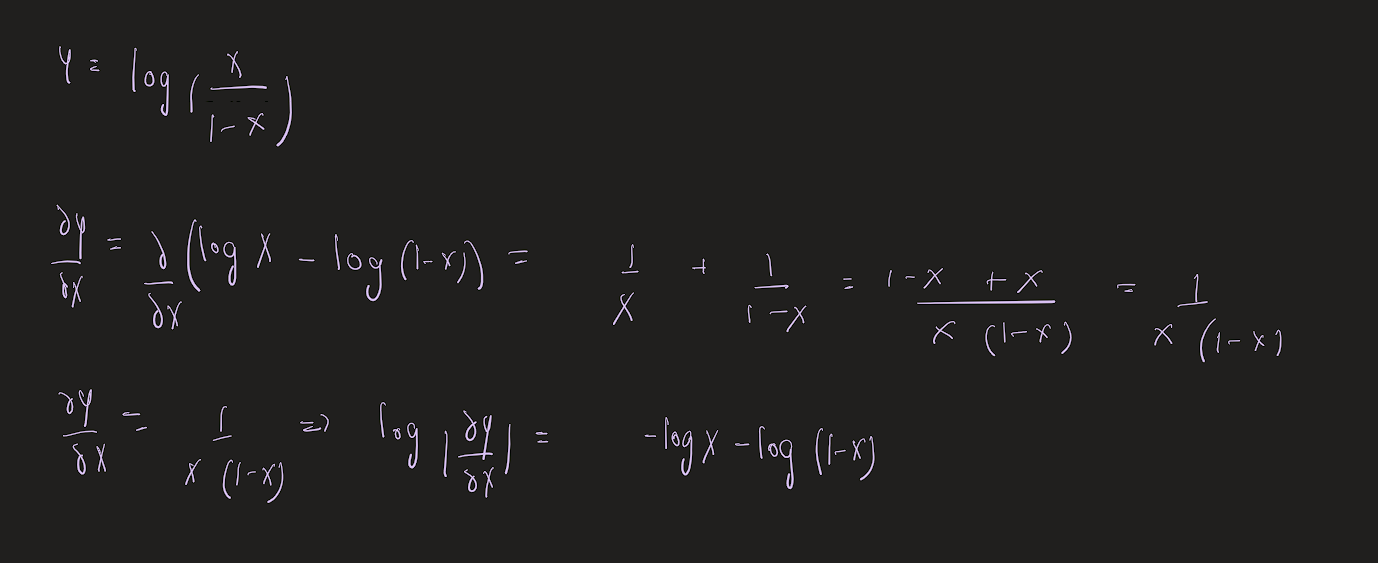

In [14]:
class Dequantization(nn.Module):
    """
    This implements the dequantization  logic discussed in paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    The Problem:
        Model Assumes the Data as,
            x ∈ R (continuous, unbounded)
        But images are x ∈ {0,1,...,255}  
        → discrete (Problem)
        → scaled to [0,1]  → bounded (Problem)

        we want out image to lie in continous space and must be unbounded (for this 'unbounded' property we use logit transformation)

        Solution: 
            1. Use Dequantization and Logit Transform
    
    This class is Only Resposible for dequantization and [logit transform (discussed in 4.1 Procedure) must be implemented in another module]
    """
    def __init__(self):
        super().__init__()

    @abstractmethod
    def forward(self, x: torch.Tensor):
        return x + (torch.rand_like(x) / 256.0)

class LogitTransform(nn.Module):
    """
    This Implements the Logit Transformation logic (discussed in 4.1 Procedure) of paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    Problem: Images are bounded in nature [0, 256] or scaled version are bounded in [0, 1] we want an unbounded space
    
    Solution: so we transform out image as, logit(a + (1 - a) x), where a = 0.05 and then applies log for removing the bounds

    We use this after the Dequantization step
    """
    def __init__(self):
        super().__init__()

    
    @abstractmethod
    def forward(self, x: torch.Tensor, alpha: float = 1e-5):
        eps = 1e-6
        x = alpha + (1 - 2 * alpha) * x
        x = torch.clamp(x, 1e-6, 1 - 1e-6)
        y = torch.log(x + eps) - torch.log(1 - x + eps)

        # get the log_det or log(del(y)/del(x))
        log_det = torch.sum(
            -torch.log(x + eps) - torch.log(1 - x + eps),
            dim = [1, 2, 3]
        )

        return y, log_det

In [15]:
import math
LOG_2PI = math.log(2 * math.pi)
def log_pz(z: torch.Tensor):
    return -0.5 * (LOG_2PI + z ** 2)

In [16]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import numpy as np

def visualize_flow(model, loader, device, epoch, num_samples=64):
    model.eval()

    with torch.no_grad():

        # 1. Generate samples (z → x)
        for images, _ in loader:
            images = images.to(device)
            x = images[:1]
            z, _ = model(x)
            # z_shape = z.shape[1:]  # (C, H, W)
            break

        z_dim = z.shape[1]
        z = torch.randn(num_samples, z_dim).to(device)
        x_gen = model.inverse(z)
        x_gen = (x_gen - x_gen.min()) / (x_gen.max() - x_gen.min() + 1e-8)

        # reverse logit approx
        # x_gen = torch.sigmoid(x_gen)

        grid = make_grid(x_gen, nrow=8)
        grid_img = grid.permute(1, 2, 0).cpu().numpy()

        # 2. Latent space scatter
        images, _ = next(iter(loader))
        images = images.to(device)

        x = images[:256]
        z, _ = model(x)
        z = z.detach().cpu()

        z_2d = z[:, :2]

        fig, ax = plt.subplots(figsize=(5,5))
        ax.scatter(z_2d[:,0], z_2d[:,1], s=5, alpha=0.6)
        ax.set_title(f"Latent Space (Epoch {epoch})")
        ax.set_xlabel("z1")
        ax.set_ylabel("z2")

        fig.canvas.draw()

        latent_img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        latent_img = latent_img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        latent_img = latent_img[..., :3]  # remove alpha

        plt.close(fig)

        plt.close(fig)
    model.train()
    return grid_img, latent_img

from torchvision.utils import make_grid
import torch

def reconstruct_and_log(model, loader, device, epoch):
    model.eval()

    with torch.no_grad():
        images, _ = next(iter(loader))
        images = images.to(device)[:64]  # take small batch

        # forward
        z, _ = model(images)

        # inverse (reconstruction)
        x_rec = model.inverse(z)

        # undo logit transform (same as generation)
        # x_rec = torch.sigmoid(x_rec)
        x_rec = (x_rec - x_rec.min()) / (x_rec.max() - x_rec.min() + 1e-8)

        # original also to [0,1] (if needed)
        x_orig = images

        # create grids
        grid_orig = make_grid(x_orig, nrow=8)
        grid_rec  = make_grid(x_rec, nrow=8)

    model.train()

    return grid_orig, grid_rec

## Logic for Saving and Loading the Model

In [17]:
import os

def save_checkpoint(model, optimizer, epoch, path="../saved_models/checkpoint.pth"):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, path)


def load_checkpoint(model, optimizer, path="checkpoint.pth", device="cuda"):
    if not os.path.exists(path):
        return 0  # start from scratch

    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    print(f"Resumed from epoch {checkpoint['epoch']}")
    return checkpoint["epoch"]

def save_periodic(model, optimizer, epoch, save_dir="checkpoints"):
    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, f"model_epoch_{epoch}.pth")

    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, path)

    print(f"Saved periodic checkpoint → {path}")


def save_best(model, optimizer, epoch, best_idx, loss, save_dir="checkpoints"):
    os.makedirs(save_dir, exist_ok=True)

    path = os.path.join(save_dir, f"best_{best_idx:02d}_epoch_{epoch}_loss_{loss:.2f}.pth")

    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "loss": loss
    }, path)

    print(f"New best model saved → {path}")

## Loading Dataset

In [18]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="../data/celeba",
    transform=transform
)

loader = DataLoader(dataset, batch_size=64, shuffle=True)

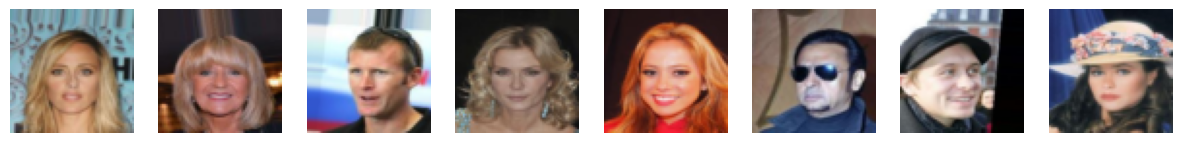

In [19]:
import matplotlib.pyplot as plt

images, labels = next(iter(loader))

fig, axes = plt.subplots(1, 8, figsize=(15,3))

for i in range(8):
    axes[i].imshow(images[i].permute(1,2,0))
    axes[i].axis("off")

plt.show()

## Build the Model

In [20]:
from torch.utils.data import DataLoader


## Build the Model
images, labels = next(iter(loader))
x = images[0]

C, H, W = x.shape
model = RectifiedCNNRNVPModel(
    in_channel = C,
    n_scale_shift_layers = 2,
    n_scale_blocks = 1
)


# Training Settings
EPOCHS = 200
lr = 1e-4
warm_epochs = 15
max_scale = 0.5
optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = 1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=50, gamma=0.5
)


loader = DataLoader(
    dataset,
    batch_size = 64,
    shuffle=True,        
    num_workers=3,       
    pin_memory=True      
)

## Experiment Tracking

In [21]:
# import wandb

# wandb.init(
#     project="realnvp-celeba",
#     name=f"run_lr{optimizer.param_groups[0]['lr']}_layers{len(list(model.modules()))}",
#     config={
#         "lr": optimizer.param_groups[0]['lr'],
#         "epochs": EPOCHS,
#         "batch_size": loader.batch_size,
#         "max_scale": max_scale,
#         "warm_epochs": warm_epochs,
#         "n_params": sum(p.numel() for p in model.parameters()),
#         "model_arch": str(model) # architecture snapshot
#     }
# )

## Train the Model

In [22]:
from tqdm import tqdm
import torch

# def set_scale_factor(model, value):
#     for m in model.modules():
#         if hasattr(m, "scale_factor"):
#             m.scale_factor.data.fill_(value)


def test_invertibility(model, device):
    print("Testing invertibility...")
    model.eval()
    model = model.to(device)
    with torch.no_grad():
        # Test forward-inverse roundtrip
        x = torch.randn(4, 3, 64, 64).to(device)
        z, log_J = model(x)
        x_reconstructed = model.inverse(z)
        
        reconstruction_error = (x - x_reconstructed).abs().mean()
        print(f"reconstruction error: {reconstruction_error:.2e}")
        
        if reconstruction_error > 1e-4:
            print(f"Warning: Reconstruction error is large!")
        else:
            print("Reconstruction error is low [SAFE]")
        
        # Test log_J shape
        print(f"✓ z shape: {z.shape}")
        print(f"✓ log_J shape: {log_J.shape}")
        
        assert log_J.shape[0] == x.shape[0], "log_J batch size mismatch"
        
        # Test for NaN
        assert not z.isnan().any(), "z contains NaN"
        assert not log_J.isnan().any(), "log_J contains NaN"
        print("✓ No NaN values detected")
        
        # Test z distribution (should be ~N(0,1))
        z_flat = z.view(z.shape[0], -1)
        print(f"✓ z mean: {z_flat.mean().item():.3f} (should be ~0)")
        print(f"✓ z std: {z_flat.std().item():.3f} (should be ~1)")

def train_model(
    model,
    optimizer,
    scheduler,
    epochs,
    loader,
    warmup_epochs: int,
    max_scale: float = 0.1,
    device="cuda",
    ckpt_path="checkpoint.pth"
):
    print(f"Training on device = [{device}]")
    
    model.to(device)
    model.train()

    dequant = Dequantization().to(device)
    # logit = LogitTransform().to(device)

    start_epoch = load_checkpoint(model, optimizer, ckpt_path, device)
    best_loss = float("inf")
    best_idx = 1

    for epoch in range(start_epoch, epochs):
        epoch_log_pz = 0
        epoch_log_J = 0
        epoch_log_det = 0
        epoch_z_mean = 0
        epoch_z_std = 0

        # --- This is for visualizing the histogram at the end of every epoch ---
        all_z_samples = []
        all_log_pz = []
        all_log_J = []

        

        progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

        # progress = min(1.0, epoch / max(1, warmup_epochs))
        # scale_value = max_scale * progress  # Linear warmup
        
        # set_scale_factor(model, scale_value)
        # -----------------------------------------------------------------------------------------------------

        for step, (images, _) in enumerate(progress_bar):
            images = images.to(device, non_blocking=True)

            x = dequant(images)
            # x, log_det_logit = logit(x)

            z, log_J = model(x)
            D = z.shape[1]

            # Latent statistics
            z_flat = z.view(z.size(0), -1)
            z_flat_hist = z.view(z.size(0), -1)
            z_mean_val = z_flat.mean().item()
            z_std_val = z_flat.std().item()

            # Loss computation
            log_pz_val = log_pz(z).flatten(1).sum(dim=1)

            # IMPORTANT: Ensure log_J has shape [B]
            if log_J.ndim > 1:
                log_J = log_J.reshape(log_J.shape[0], -1).sum(dim=1)

            # nll = -(log_pz_val + log_J + log_det_logit) / D
            nll = -(log_pz_val + log_J) / D
            # reg = 2e-4 * (log_J ** 2)
            # reg = 1e-2 * ((log_J / D) ** 2)

            latent_reg = 1e-4 * (
                z_flat.mean(dim = 1) ** 2 + ((z_flat.std(dim = 1) - 1) ** 2)
            )

            # loss = (nll + reg + latent_reg).mean()
            loss = (nll + latent_reg).mean()
            # ratio = log_J / (abs(log_pz_val) + 1e-8)
            ratio = (log_J / D) / (log_pz_val.abs() / D + 1e-8)

            z_sub = z_flat.detach().cpu()
            z_sub = z_sub.view(-1) # Flatten completely so it's a 1D array of values
            if z_sub.numel() > 2000: # Subsample per batch to save RAM
                idx = torch.randperm(z_sub.numel())[:2000]
                z_sub = z_sub[idx]
            
            all_z_samples.append(z_sub)
            all_log_pz.append(log_pz_val.detach().cpu())
            all_log_J.append(log_J.detach().cpu())

            if torch.isnan(loss) or torch.isinf(loss):
                print(f"   NaN/Inf detected at epoch {epoch+1}, step {step}")
                print(f"   log_pz_val: {log_pz_val.mean().item()}")
                print(f"   log_J: {log_J.mean().item()}")
                return model

            epoch_log_pz += log_pz_val.mean().item()
            epoch_log_J += log_J.mean().item()
            epoch_z_mean += z_mean_val
            epoch_z_std += z_std_val

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            scale_metrics = {}
            i = 0
            for m in model.modules():
                if hasattr(m, "scale_factor"):
                    scale_metrics[f"scale/layer_{i}"] = m.scale_factor.detach().cpu().item()
                    i += 1
            
            # ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
            # Histogram logging (W&B)

            # Flatten
            z_hist = z_flat_hist.detach().view(-1)
            log_pz_hist = log_pz_val.detach().view(-1)
            log_J_hist = log_J.detach().view(-1)

            # Subsample to avoid slowdown
            max_samples = 10000

            if z_hist.numel() > max_samples:
                idx = torch.randperm(z_hist.numel(), device=z_hist.device)[:max_samples]
                z_hist = z_hist[idx]

            if log_pz_hist.numel() > max_samples:
                idx = torch.randperm(log_pz_hist.numel(), device=log_pz_hist.device)[:max_samples]
                log_pz_hist = log_pz_hist[idx]

            if log_J_hist.numel() > max_samples:
                idx = torch.randperm(log_J_hist.numel(), device=log_J_hist.device)[:max_samples]
                log_J_hist = log_J_hist[idx]

            # Move to CPU
            z_hist = z_hist.cpu().numpy()
            log_pz_hist = log_pz_hist.cpu().numpy()
            log_J_hist = log_J_hist.cpu().numpy()

            # generate ideal gaussian (for reference)
            ref = np.random.normal(0, 1, size=10000)
            wandb.log({
                "hist/z_distribution": wandb.Histogram(z_hist),
                "hist/log_pz_distribution": wandb.Histogram(log_pz_hist),
                "hist/log_J_distribution": wandb.Histogram(log_J_hist),
                "hist/z_vs_gaussian": [
                    wandb.Histogram(z_hist),
                    wandb.Histogram(ref)
                ]
            })
            # ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

            wandb.log({
                "batch/loss": loss.item(),
                "batch/log_pz": log_pz_val.mean().item(),
                "batch/log_J": log_J.mean().item(),
                "batch/z_mean": z_mean_val,
                "batch/z_std": z_std_val,
                "batch/ratio": ratio,
                **scale_metrics
                # "scale_factor": scale_value
            })

        scheduler.step()

        num_batches = len(loader)
        avg_log_pz = epoch_log_pz / num_batches
        avg_log_J = epoch_log_J / num_batches
        avg_log_det = epoch_log_det / num_batches
        avg_loss = -(avg_log_pz + avg_log_J + avg_log_det) / D
        ratio = log_J.mean() / (log_pz_val.mean().abs() + 1e-8)
        avg_z_mean = epoch_z_mean / num_batches
        avg_z_std = epoch_z_std / num_batches
        bpd = avg_loss / torch.log(torch.tensor(2.0)).item()

        progress_bar.close()

        print("\n" + "-"*60)
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f" Loss     : {avg_loss:.4f}")
        print(f" log_pz   : {avg_log_pz:.2f}")
        print(f" log_J    : {avg_log_J:.2f}")
        print(f" log_det  : {avg_log_det:.2f}")
        print(f" ratio    : {ratio:.3f}")
        print(f" z_mean   : {avg_z_mean:.3f}")
        print(f" z_std    : {avg_z_std:.3f}")
        print(f" bits/dim : {bpd:.3f}")
        # print(f" scale    : {scale_value:.4f}")
        print("-"*60)

        # ----------------------------------------------------------- histogram logging -----------------------------------------------------------
        # Concatenate all collected batches
        full_z = torch.cat(all_z_samples).numpy()
        full_log_pz = torch.cat(all_log_pz).numpy()
        full_log_J = torch.cat(all_log_J).numpy()
        # -----------------------------------------------------------------------------------------------------------------------------------------

        wandb.log({
            "epoch": epoch + 1,
            "epoch/loss": avg_loss,
            "epoch/log_pz": avg_log_pz,
            "epoch/log_J": avg_log_J,
            "epoch/log_det": avg_log_det,
            "epoch/ratio": ratio,
            "epoch/z_mean": avg_z_mean,
            "epoch/z_std": avg_z_std,
            "epoch/bits_per_dim": bpd,
            # ----------------------------------------------------------- histogram logging -----------------------------------------------------------
            "hist/z_distribution": wandb.Histogram(full_z),
            "hist/log_pz_distribution": wandb.Histogram(full_log_pz),
            "hist/log_J_distribution": wandb.Histogram(full_log_J),
            # -----------------------------------------------------------------------------------------------------------------------------------------
        })

        if avg_loss < best_loss:
            best_loss = avg_loss
            save_best(model, optimizer, epoch+1, best_idx, best_loss)
            wandb.save(f"checkpoints/best_{best_idx}.pth")
            best_idx += 1

        if (epoch + 1) % 30 == 0:
            save_periodic(model, optimizer, epoch+1)

        save_checkpoint(model, optimizer, epoch+1, ckpt_path)
        wandb.save(ckpt_path)

        ## Visualization of Latent space, reconstruction and Sampling, saved in weights and bias
        if (epoch + 1) % 1 == 0:
            gen_img, latent_img = visualize_flow(model, loader, device, epoch+1)
            orig_img, rec_img = reconstruct_and_log(model, loader, device, epoch+1)

            wandb.log({
                "generated_samples": wandb.Image(gen_img, caption=f"Epoch {epoch+1}"),
                "latent_space": wandb.Image(latent_img),
                "reconstruction/original": wandb.Image(orig_img),
                "reconstruction/reconstructed": wandb.Image(rec_img)
            })

    return model

## Testing reconstruction error

In [23]:
test_invertibility(model, device)

Testing invertibility...
reconstruction error: 0.00e+00
Reconstruction error is low [SAFE]
✓ z shape: torch.Size([4, 12288])
✓ log_J shape: torch.Size([4])
✓ No NaN values detected
✓ z mean: -0.002 (should be ~0)
✓ z std: 1.002 (should be ~1)


In [24]:
# trained_model = train_model(model,
#                             optimizer = optimizer,
#                             epochs = EPOCHS,
#                             loader = loader,
#                             device = device,
#                             scheduler = scheduler,
#                             warmup_epochs = warm_epochs,
#                             max_scale = max_scale)

## [Debugging]: Training the model on a small batch of 32 images again and again untill loss = 0

In [25]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="../data/celeba",
    transform=transform
)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

images, labels = next(iter(loader))
images.shape

torch.Size([32, 3, 64, 64])

In [26]:
images = images.to(device, non_blocking=True)
z, log_J = model(images[:1])
z.shape, log_J.shape, log_pz(z).flatten(1).sum(dim=1)

(torch.Size([1, 12288]),
 torch.Size([1]),
 tensor([-13158.4014], device='cuda:0', grad_fn=<SumBackward1>))

In [27]:
model.to(device)
model.train()

dequant = Dequantization().to(device)
logit = LogitTransform().to(device)

images = images.to(device, non_blocking=True)

# Overfitting the model on small batch_size of 32 images and training it untill the loss is approx 0
for epoch in range(10000):
    x = dequant(images)
    # x, log_det_logit = logit(x)

    z, log_J = model(x)
    D = z.shape[1]

    # Latent statistics
    z_flat = z.view(z.size(0), -1)
    z_mean_val = z_flat.mean().item()
    z_std_val = z_flat.std().item()

    # Loss computation
    log_pz_val = log_pz(z).flatten(1).sum(dim=1)

    # IMPORTANT: Ensure log_J has shape [B]
    if log_J.ndim > 1:
        log_J = log_J.reshape(log_J.shape[0], -1).sum(dim=1)

    # nll = -(log_pz_val + log_J + log_det_logit)
    nll = -(log_pz_val + log_J)

    loss = nll.mean()


    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch = {epoch} | loss = {loss:.3f} | z_mean = {z_mean_val:.3f} | z_std = {z_std_val:.3f}")


Epoch = 0 | loss = 12753.985 | z_mean = 0.395 | z_std = 0.286
Epoch = 1 | loss = 12516.313 | z_mean = 0.383 | z_std = 0.283
Epoch = 2 | loss = 12283.424 | z_mean = 0.371 | z_std = 0.280
Epoch = 3 | loss = 12053.043 | z_mean = 0.359 | z_std = 0.278
Epoch = 4 | loss = 11823.568 | z_mean = 0.347 | z_std = 0.276
Epoch = 5 | loss = 11592.996 | z_mean = 0.334 | z_std = 0.274
Epoch = 6 | loss = 11359.161 | z_mean = 0.322 | z_std = 0.272
Epoch = 7 | loss = 11119.594 | z_mean = 0.309 | z_std = 0.271
Epoch = 8 | loss = 10871.561 | z_mean = 0.295 | z_std = 0.270
Epoch = 9 | loss = 10612.000 | z_mean = 0.281 | z_std = 0.269
Epoch = 10 | loss = 10337.561 | z_mean = 0.266 | z_std = 0.269
Epoch = 11 | loss = 10044.283 | z_mean = 0.250 | z_std = 0.270
Epoch = 12 | loss = 9727.630 | z_mean = 0.232 | z_std = 0.273
Epoch = 13 | loss = 9382.100 | z_mean = 0.214 | z_std = 0.277
Epoch = 14 | loss = 9001.586 | z_mean = 0.194 | z_std = 0.284
Epoch = 15 | loss = 8578.483 | z_mean = 0.172 | z_std = 0.294
Epoch 

KeyboardInterrupt: 

In [28]:
z, _ = model(images)
z_dim = z.shape[-1]
z = torch.randn(64, z_dim).to(device)
x = model.inverse(z)
x = torch.sigmoid(x)

print(x.min(), x.max(), x.mean())

tensor(0.3524, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.8231, device='cuda:0', grad_fn=<MaxBackward1>) tensor(0.5895, device='cuda:0', grad_fn=<MeanBackward0>)


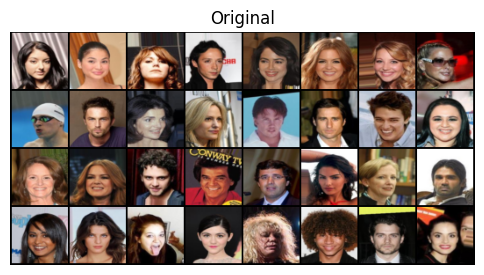

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.6988613e-05..1.0000688].


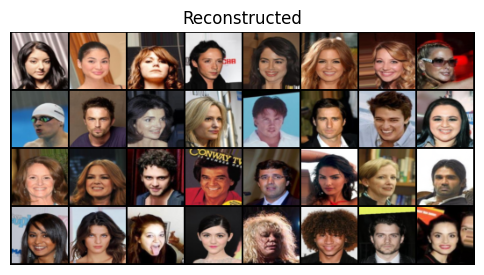

In [29]:
def reconstruct_and_log_1(model, images, device):
    model.eval()

    with torch.no_grad():
        images = images.to(device)[:64]  # take small batch

        # forward
        z, _ = model(images)

        # inverse (reconstruction)
        x_rec = model.inverse(z)

        # undo logit transform (same as generation)
        # x_rec = torch.sigmoid(x_rec)

        # original also to [0,1] (if needed)
        x_orig = images

        # create grids
        grid_orig = make_grid(x_orig, nrow=8)
        grid_rec  = make_grid(x_rec, nrow=8)

    model.train()

    return grid_orig, grid_rec
grid_orig, grid_rec = reconstruct_and_log_1(model, images, device)

import matplotlib.pyplot as plt

# convert BEFORE plotting
grid_orig = grid_orig.permute(1, 2, 0).cpu().numpy()
grid_rec  = grid_rec.permute(1, 2, 0).cpu().numpy()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(grid_orig)
plt.title("Original")
plt.axis('off')
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(grid_rec)
plt.title("Reconstructed")
plt.axis('off')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.35346937..1.3127002].


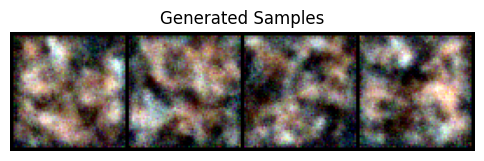

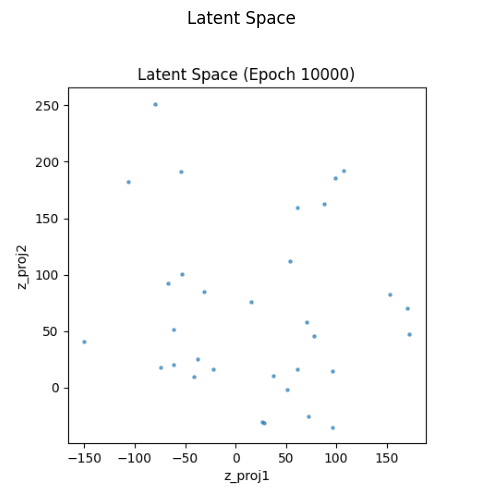

In [30]:
def visualize_flow(model, images, device, epoch, num_samples=64):
    model.eval()

    with torch.no_grad():

        # =========================
        # 1. Generate samples (z → x)
        # =========================
        images = images.to(device)

        # get latent dimension properly
        x = images[:1]
        z, _ = model(x)
        z_dim = z.shape[1]

        # sample from N(0,1)
        z = torch.randn(num_samples, z_dim).to(device)

        # inverse flow
        x_gen = model.inverse(z)

        # IMPORTANT: clamp before sigmoid (prevents weird artifacts)
        # x_gen = torch.sigmoid(x_gen.clamp(-10, 10))

        grid = make_grid(x_gen, nrow=8)
        grid_img = grid.permute(1, 2, 0).cpu().numpy()


        # =========================
        # 2. Latent space visualization
        # =========================
        x = images[:256]
        z, _ = model(x)
        z = z.detach().cpu()

        # ❗ better than z[:, :2]
        # random projection → avoids dead dims issue
        proj = torch.randn(z.shape[1], 2)
        z_2d = (z @ proj).numpy()

        fig, ax = plt.subplots(figsize=(5,5))
        ax.scatter(z_2d[:, 0], z_2d[:, 1], s=5, alpha=0.6)
        ax.set_title(f"Latent Space (Epoch {epoch})")
        ax.set_xlabel("z_proj1")
        ax.set_ylabel("z_proj2")

        fig.canvas.draw()

        latent_img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        latent_img = latent_img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        latent_img = latent_img[..., :3]

        plt.close(fig)

    model.train()
    return grid_img, latent_img
grid_img, latent_img = visualize_flow(model, images, device, 10000, num_samples = 4)


import matplotlib.pyplot as plt

# show generated samples
plt.figure(figsize=(6,6))
plt.imshow(grid_img)
plt.title("Generated Samples")
plt.axis('off')
plt.show()

# show latent space
plt.figure(figsize=(6,6))
plt.imshow(latent_img)
plt.title("Latent Space")
plt.axis('off')
plt.show()

### Completed so far:
1. Understood coupling layers
2. Implemented checkerboard masking
3. Implemented channel-wise masking
4. Understood broadcasting optimization
5. Implemented squeeze operation correctly
6. Designed modular architecture
7. Identified multi-scale factoring but intentionally postponed it
8. Implement Scale and Shift Network (using rectified convolutions)
9. Implement Residual Skip Connections
10. Implement Batch Normalization
11. Implement Affine Coupling Layer
12. Implement Forward Block of the entire network
13. Implement Inverse of this invertible functio
14. Implement multi-scale factoring
15. Implement Inverse mapping for each invertible functions
16. Implement inverse for SqueezingOperator also
17. Implemented inverse mapping for entire model (handled concat and flattening logic of latent variable `z`)
18. Storage of |J| (Determinant Jacobian)
19. dequantization and scaling of images (as described in the paper) and add the contribution of it in Log_J as `log p(x) = log p(z) + log|det J_flow| + log|det J_logit|`
20. Convert all tensor to device
21. Build Model
22. Write training loop and handle dataloading loop
23. Train the Model

### Todo:
1. Monitor training and Visualize results, Debug errors